#### 1. Análise inicial

In [4]:
# Importando as bibliotecas
import pandas as pd

# Carregando a base de dados
base_dados = pd.read_csv('titanic.csv', sep = ';', decimal=',')# Visualizando as primeiras linhas da base
df = base_dados

In [12]:
print(base_dados.head())

  sobreviveu    classe       sexo idade  irmaos_conjuges  pais_filhos  \
0        nao  terceira  masculino    22                1            0   
1        sim  primeira   feminino    38                1            0   
2        sim  terceira   feminino    26                0            0   
3        sim  primeira   feminino    35                1            0   
4        nao  terceira  masculino    35                0            0   

  valor_tarifa nivel_cabine     embarque  
0         7,25          NaN  Southampton  
1        71,28            C    Cherbourg  
2         7,93          NaN  Southampton  
3        53,10            C  Southampton  
4         8,05          NaN  Southampton  


In [ ]:
print(base_dados.shape)

(891, 9)


In [2]:
# Mostra os valores únicos (ex: [1, 2, 3])
print(df['classe'].unique())

<StringArray>
['terceira', 'primeira', 'segunda']
Length: 3, dtype: str


In [36]:
# 1. Arredonda (0 casas decimais)
# 2. Converte para Int64 (o 'I' maiúsculo aceita valores nulos)
df['idade'] = df['idade'].round(0).astype('Int64')

In [40]:
print(base_dados.dtypes)

sobreviveu             str
classe                 str
sexo                   str
idade                Int64
irmaos_conjuges      int64
pais_filhos          int64
valor_tarifa       float64
nivel_cabine           str
embarque               str
dtype: object


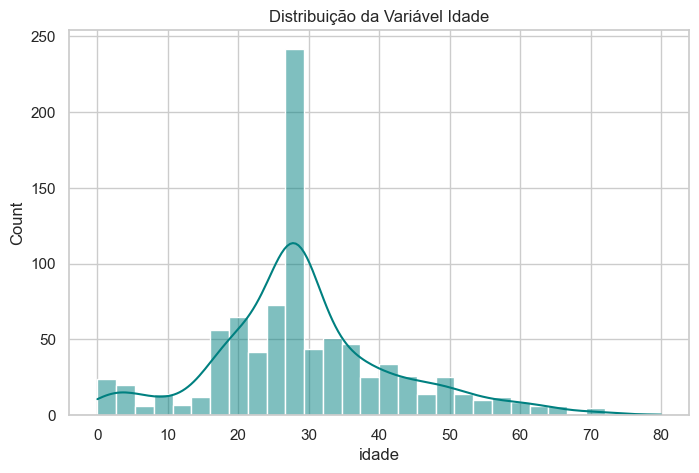

In [37]:
plt.figure(figsize=(8, 5))
sns.histplot(df['idade'], kde=True, color='teal')
plt.title('Distribuição da Variável Idade')
plt.show()

In [41]:
# Calculando a média e o desvio padrão
media = df['idade'].mean()
desvio = df['idade'].std()

# Aplicando a fórmula do Z-Score
df['idade_zscore'] = (df['idade'] - media) / desvio

print(df[['idade', 'idade_zscore']].head())

   idade  idade_zscore
0     22     -0.565141
1     38      0.663944
2     26      -0.25787
3     35       0.43349
4     35       0.43349


In [5]:
mediana = df['idade'].median()
df['idade'] = df['idade'].fillna(mediana)

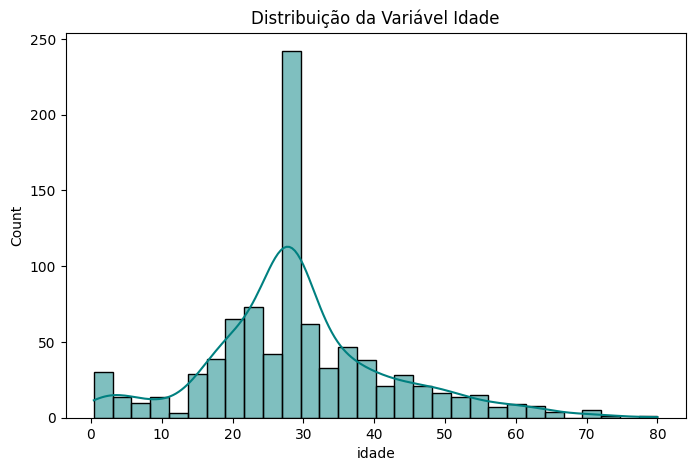

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Now your code will work
plt.figure(figsize=(8, 5))
sns.histplot(df['idade'], kde=True, color='teal')
plt.title('Distribuição da Variável Idade')
plt.show() # Good practice to include this to display the plot cleanly

#### 2. Boxplot

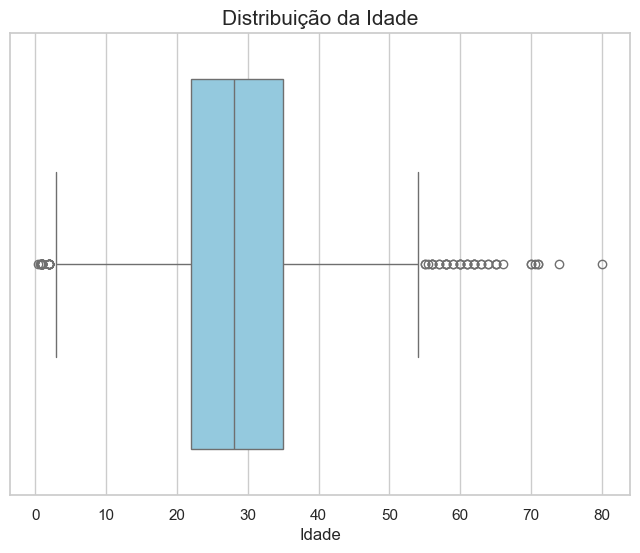

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definindo o estilo visual
sns.set_theme(style="whitegrid")

# Criando o boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=base_dados['idade'], color='skyblue')

# Adicionando títulos e rótulos
plt.title('Distribuição da Idade', fontsize=15)
plt.xlabel('Idade')

# Exibindo o gráfico
plt.show()

#### 3. DBSCAN

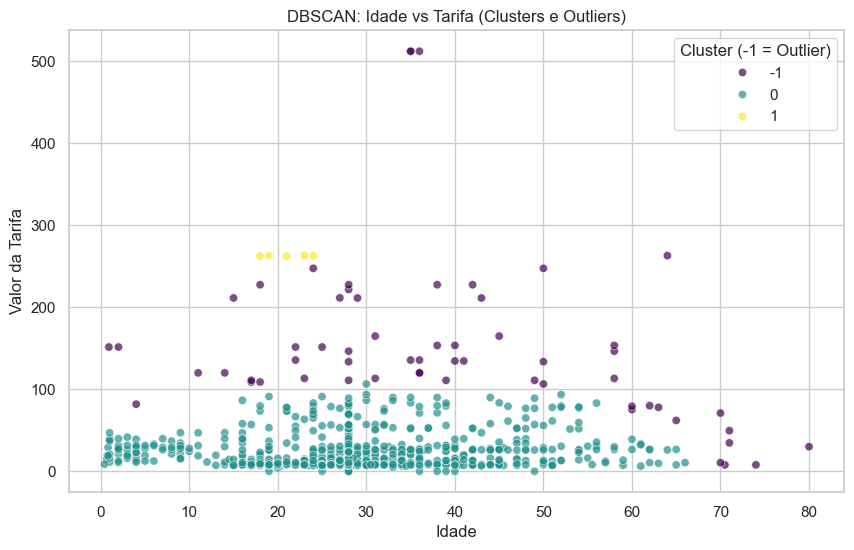

In [34]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

df = base_dados
# 1. Tratamento do erro '28,5' (Conversão de vírgula para ponto)
# Convertendo para string primeiro para garantir que o .str funcione
df['idade'] = df['idade'].astype(str).str.replace(',', '.')
df['idade'] = pd.to_numeric(df['idade'], errors='coerce')

# 2. Limpeza de valores nulos (DBSCAN não aceita NaNs)
df_clean = df[['idade', 'valor_tarifa']].dropna()

# 3. Normalização (Essencial para algoritmos de distância)
scaler = StandardScaler()
dados_scaled = scaler.fit_transform(df_clean)

# 4. Configurando e aplicando o DBSCAN
# eps: raio da vizinhança | min_samples: pontos mínimos para um cluster
dbscan = DBSCAN(eps=0.3, min_samples=5)
df_clean['cluster'] = dbscan.fit_predict(dados_scaled)

# 5. Visualização Corrigida (usando 'marker' em vez de 'pch')
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean, 
    x='idade', 
    y='valor_tarifa', 
    hue='cluster', 
    palette='viridis', 
    marker='o',  # O 'pch' do R aqui é 'marker'
    alpha=0.7
)

plt.title('DBSCAN: Idade vs Tarifa (Clusters e Outliers)')
plt.xlabel('Idade')
plt.ylabel('Valor da Tarifa')
plt.legend(title='Cluster (-1 = Outlier)')
plt.show()

In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Limpeza (Z-score não aceita nulos)
idade_limpa = df['idade'].dropna()

# 2. Cálculo do Z-score
idade_z = stats.zscore(idade_limpa)

# 3. Visualização
plt.figure(figsize=(10, 6))
sns.histplot(idade_z, kde=True, color='purple', alpha=0.4)

# Adicionando linhas de referência
plt.axvline(x=0, color='red', linestyle='-', linewidth=2, label='Média (Z=0)')
plt.axvline(x=1, color='orange', linestyle='--', linewidth=1.5, label='1 Desvio Padrão (+1)')
plt.axvline(x=-1, color='orange', linestyle='--', linewidth=1.5, label='1 Desvio Padrão (-1)')
plt.axvline(x=3, color='black', linestyle=':', linewidth=1.5, label='Limite de Outlier (+3)')
plt.axvline(x=-3, color='black', linestyle=':', linewidth=1.5, label='Limite de Outlier (-3)')

plt.title('Distribuição Padronizada (Z-Score) da Idade', fontsize=15)
plt.xlabel('Z-Score da Idade')
plt.ylabel('Frequência')
plt.legend()
plt.show()

Gráficos de variáveis

In [20]:
import pandas as pd

# 1. Definindo os cortes personalizados
# 0-24, 25-49, 50-59, e 60+ (até 100)
bins = [0, 25, 50, 60, 100]
labels = ['0-24', '25-49', '50-59', '60+']

# 2. Criando a nova coluna de faixas
df['faixa_agrupada'] = pd.cut(df['idade'], bins=bins, labels=labels, right=False)

# 3. Gerando a tabela de taxas reais
tabela_senior = df.groupby('faixa_agrupada').agg(
    total_pessoas=('sobreviveu_num', 'count'),
    total_sobreviventes=('sobreviveu_num', 'sum'),
    taxa_real=('sobreviveu_num', 'mean')
).reset_index()

# 4. Formatação para o print
tabela_senior['taxa_formatada'] = (tabela_senior['taxa_real'] * 100).round(2).astype(str) + '%'

print("Análise com Grupo Sênior Agrupado:")
print(tabela_senior[['faixa_agrupada', 'total_pessoas', 'total_sobreviventes', 'taxa_formatada']])

Análise com Grupo Sênior Agrupado:
  faixa_agrupada  total_pessoas  total_sobreviventes taxa_formatada
0           0-24            278                  118         42.45%
1          25-49            539                  197         36.55%
2          50-59             48                   20         41.67%
3            60+             26                    7         26.92%


C:\Users\geova\AppData\Local\Temp\ipykernel_10756\2434051292.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


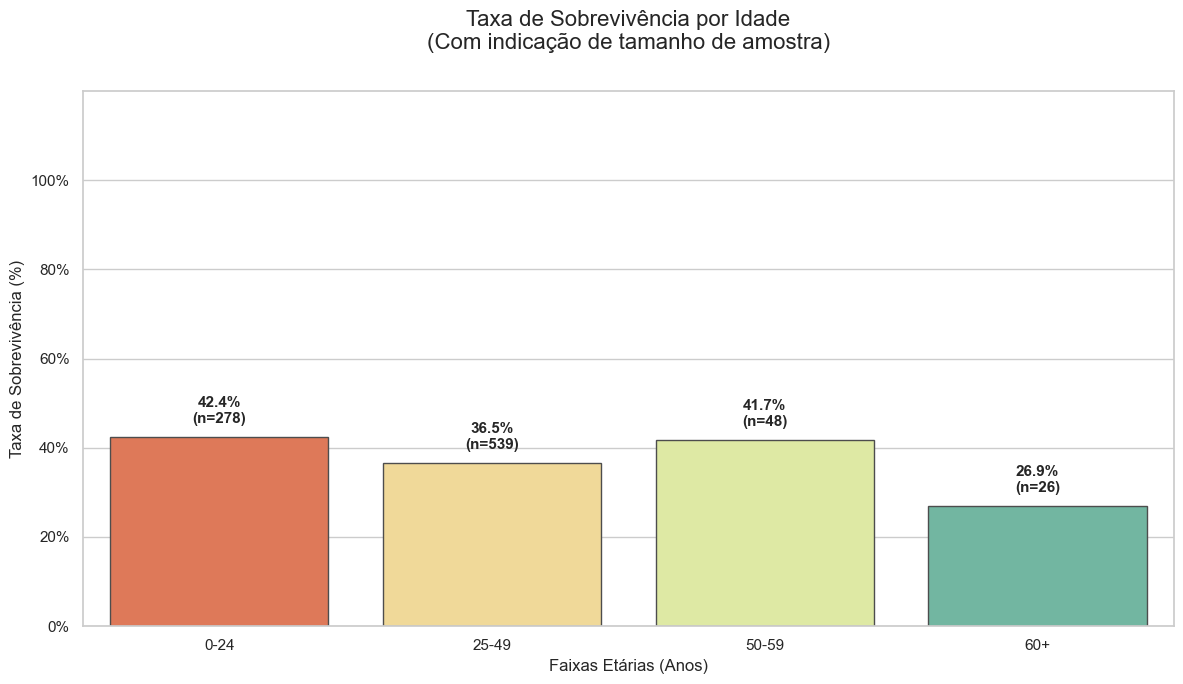

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configurações Visuais
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# 2. Criando o gráfico
# Usamos uma paleta de cores que vai do frio (menor taxa) ao quente (maior taxa)
ax = sns.barplot(
    data=tabela_senior, 
    x='faixa_agrupada', 
    y='taxa_real', 
    palette='Spectral',
    edgecolor='0.3'
)

# 3. Mágica dos Rótulos: % + n (amostra)
for i, p in enumerate(ax.patches):
    taxa = tabela_senior.iloc[i]['taxa_real'] * 100
    n_total = tabela_senior.iloc[i]['total_pessoas']
    
    # Criamos uma string com a porcentagem e o total de pessoas abaixo
    label = f'{taxa:.1f}%\n(n={n_total})'
    
    ax.annotate(label, 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', 
                xytext=(0, 8), 
                textcoords='offset points')

# 4. Ajustes de Eixos e Títulos
plt.title('Taxa de Sobrevivência por Idade\n(Com indicação de tamanho de amostra)', fontsize=16, pad=30)
plt.ylabel('Taxa de Sobrevivência (%)', fontsize=12)
plt.xlabel('Faixas Etárias (Anos)', fontsize=12)
plt.ylim(0, 1.2) # Espaço para os rótulos não serem cortados

# Transforma o eixo Y em porcentagem real
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0], ['0%', '20%', '40%', '60%', '80%', '100%'])

plt.tight_layout()
plt.show()

In [11]:
# 1. Garante que o texto esteja minúsculo e sem espaços sobrando
df['sobreviveu'] = df['sobreviveu'].str.lower().str.strip()

# 2. Converte para 1 (Sim) e 0 (Não) - o .map é bem rigoroso aqui
df['sobreviveu_num'] = df['sobreviveu'].map({'sim': 1, 'nao': 0})

# 3. Agora gera a tabela de gênero
tabela_genero = df.groupby('sexo').agg(
    total_pessoas=('sobreviveu_num', 'count'),
    total_sobreviventes=('sobreviveu_num', 'sum'),
    taxa_real=('sobreviveu_num', 'mean')
).reset_index()

# 4. Formata para o relatório
tabela_genero['taxa_formatada'] = (tabela_genero['taxa_real'] * 100).round(2).astype(str) + '%'

print(tabela_genero)

        sexo  total_pessoas  total_sobreviventes  taxa_real taxa_formatada
0   feminino            314                  233   0.742038          74.2%
1  masculino            577                  109   0.188908         18.89%


C:\Users\geova\AppData\Local\Temp\ipykernel_10756\3627840108.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=generos, y=taxas_reais, palette=cores, edgecolor='0.3')


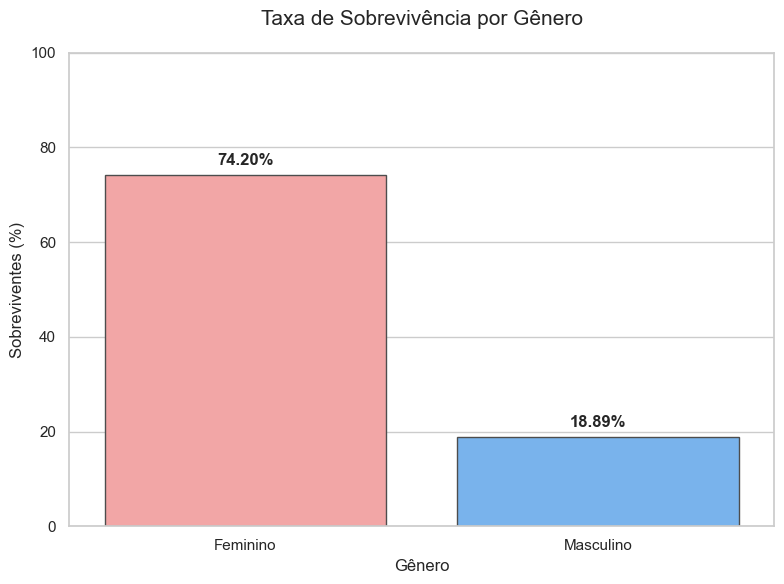

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dados Reais e Independentes
generos = ['Feminino', 'Masculino']
taxas_reais = [74.20, 18.89]
cores = ['#ff9999', '#66b3ff']

# 2. Configuração da Figura
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# 3. Criação do Gráfico de Barras
ax = sns.barplot(x=generos, y=taxas_reais, palette=cores, edgecolor='0.3')

# 4. Inserção de Rótulos (A porcentagem real no topo de cada barra)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=12, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

# 5. Ajustes de Eixos e Título
plt.title('Taxa de Sobrevivência por Gênero', fontsize=15, pad=20)
plt.ylabel('Sobreviventes (%)', fontsize=12)
plt.xlabel('Gênero', fontsize=12)
plt.ylim(0, 100) # Mantém a escala de 0 a 100% para evitar distorção visual

plt.tight_layout()
plt.show()

In [22]:
# Gerando a tabela de taxa real por classe
tabela_classe_real = df.groupby('classe').agg(
    total_passageiros=('sobreviveu_num', 'count'),
    total_sobreviventes=('sobreviveu_num', 'sum'),
    taxa_sobrevivencia=('sobreviveu_num', 'mean')
).reset_index()

# Formatando para porcentagem
tabela_classe_real['taxa_sobrevivencia'] = (tabela_classe_real['taxa_sobrevivencia'] * 100).round(2).astype(str) + '%'

print(tabela_classe_real)

     classe  total_passageiros  total_sobreviventes taxa_sobrevivencia
0  primeira                216                  136             62.96%
1   segunda                184                   87             47.28%
2  terceira                491                  119             24.24%


C:\Users\geova\AppData\Local\Temp\ipykernel_10756\2725531943.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=categorias, y=taxas_reais, palette=cores, edgecolor='0.3')


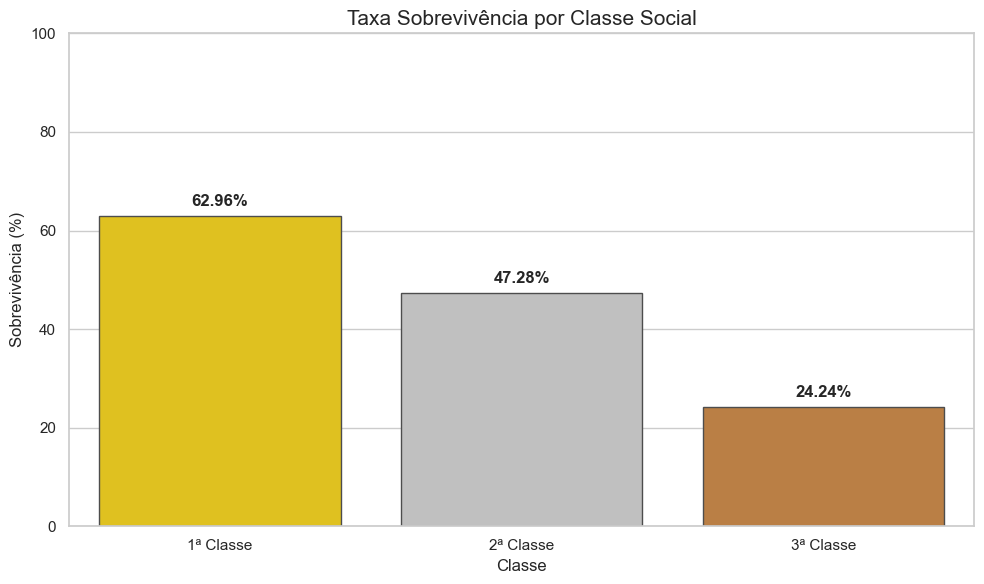

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definindo os dados exatos (Taxas Reais que você calculou)
categorias = ['1ª Classe', '2ª Classe', '3ª Classe']
taxas_reais = [62.96, 47.28, 24.24]
cores = ['#ffd700', '#c0c0c0', '#cd7f32'] # Ouro, Prata e Bronze

# 2. Configuração do estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Criando o gráfico de barras
# O segredo é que cada barra sobe até o seu valor real no eixo Y
ax = sns.barplot(x=categorias, y=taxas_reais, palette=cores, edgecolor='0.3')

# 4. Adicionando os rótulos de texto no topo de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=12, fontweight='bold', 
                xytext=(0, 5), 
                textcoords='offset points')

# 5. Ajustes de escala e títulos
plt.title('Taxa Sobrevivência por Classe Social', fontsize=15)
plt.ylabel('Sobrevivência (%)', fontsize=12)
plt.xlabel('Classe', fontsize=12)

plt.ylim(0, 100) 

plt.tight_layout()
plt.show()

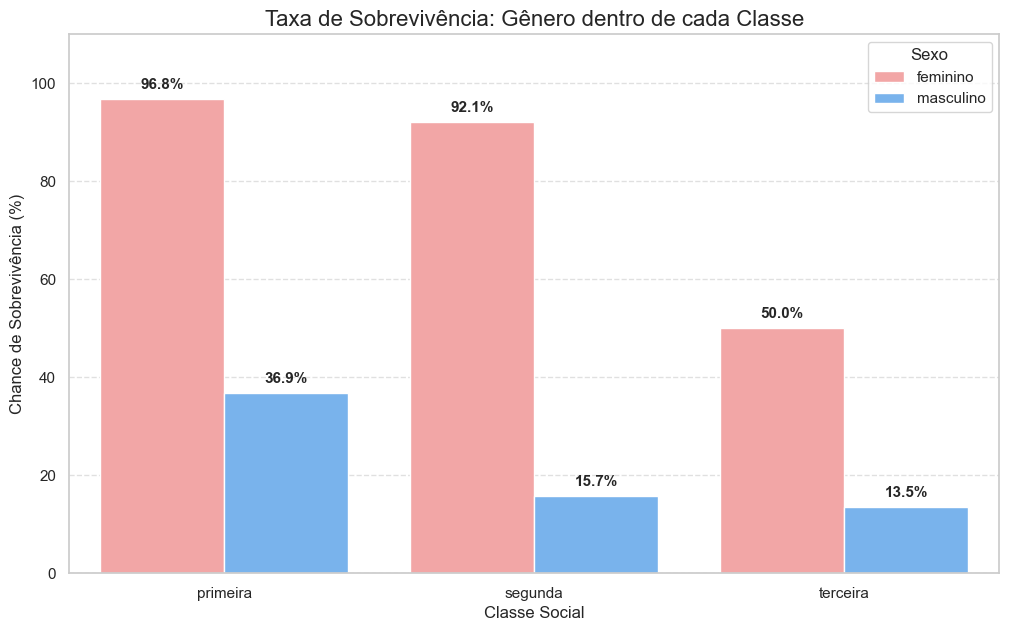

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculando a taxa real agrupada por classe e sexo
tabela_cruzada = df.groupby(['classe', 'sexo']).agg(
    taxa_sobrevivencia=('sobreviveu_num', 'mean')
).reset_index()

# Converte para porcentagem (0.96 -> 96.0)
tabela_cruzada['taxa_sobrevivencia'] *= 100

# 2. Criando o gráfico de barras agrupadas
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=tabela_cruzada, 
    x='classe', 
    y='taxa_sobrevivencia', 
    hue='sexo', 
    palette=['#ff9999', '#66b3ff'] # Rosa para mulheres, Azul para homens
)

# 3. Adicionando os rótulos de porcentagem exata
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', 
                    fontsize=11, fontweight='bold', xytext=(0, 5),
                    textcoords='offset points')

# 4. Ajustes de layout
plt.title('Taxa de Sobrevivência: Gênero dentro de cada Classe', fontsize=16)
plt.ylabel('Chance de Sobrevivência (%)')
plt.xlabel('Classe Social')
plt.ylim(0, 110) # Espaço extra para as etiquetas no topo
plt.legend(title='Sexo')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

### Vamos ver


In [8]:
import pandas as pd

# Use read_csv com o separador ';' que vimos na sua imagem
df = pd.read_csv('titanic.csv', sep=';', decimal=',')

# Para confirmar que carregou todas as colunas corretamente:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sobreviveu       891 non-null    str    
 1   classe           891 non-null    str    
 2   sexo             891 non-null    str    
 3   idade            714 non-null    float64
 4   irmaos_conjuges  891 non-null    int64  
 5   pais_filhos      891 non-null    int64  
 6   valor_tarifa     891 non-null    float64
 7   nivel_cabine     203 non-null    str    
 8   embarque         889 non-null    str    
dtypes: float64(2), int64(2), str(5)
memory usage: 62.8 KB
None


In [14]:
import pandas as pd
import os

# Pega o nome do arquivo diretamente (ele deve estar na mesma pasta do código)
nome_arquivo = 'titanic.csv'

if os.path.exists(nome_arquivo):
    df = pd.read_csv(nome_arquivo, sep=';', decimal=',')
    print("Arquivo carregado com sucesso usando caminho relativo!")
    
    # Prossegue com a renomeação
    df = df.rename(columns={'sexo': 'gênero'})
    # ... resto do seu código de mapeamento ...
else:
    print(f"Erro: O arquivo '{nome_arquivo}' não está na pasta do script.")
    print(f"Diretório atual: {os.getcwd()}")

Arquivo carregado com sucesso usando caminho relativo!


In [20]:
pip install --upgrade numpy

Note: you may need to restart the kernel to use updated packages.


In [16]:
# Verifica se a transformação de 'gênero' não gerou valores nulos inesperados
print("Distribuição após tratamento:")
print(df['gênero'].value_counts())

# Verifica os tipos de dados para confirmar se 'valor_tarifa' é numérico
print("\nTipos de dados atuais:")
print(df.dtypes)

Distribuição após tratamento:
gênero
Masculino    577
Feminino     314
Name: count, dtype: int64

Tipos de dados atuais:
sobreviveu             str
classe                 str
gênero                 str
idade              float64
irmaos_conjuges      int64
pais_filhos          int64
valor_tarifa       float64
nivel_cabine           str
embarque               str
dtype: object


In [17]:
# Padronizando as faixas etárias (Criança/Adulto/Idoso)
bins = [0, 12, 100]
labels = ['Criança (0-12)', 'Adulto (13+)']
df['faixa_etaria'] = pd.cut(df['idade'], bins=bins, labels=labels)

# 1. Ler o formato das variáveis 
print(df.dtypes)


sobreviveu              str
classe                  str
gênero                  str
idade               float64
irmaos_conjuges       int64
pais_filhos           int64
valor_tarifa        float64
nivel_cabine            str
embarque                str
faixa_etaria       category
dtype: object


In [18]:
# 2. TRANSFORMAÇÃO DE FORMATOS E TIPOS

# A. Dummificação da variável 'sobreviveu' (1=sim, 0=nao)
df['sobreviveu'] = df['sobreviveu'].map({'sim': 1, 'nao': 0})

# B. (mantido comentado como você já fez)
# df['gênero'] = df['gênero'].map({'feminino': 1, 'masculino': 0})

# C. Categorização Ordinal da variável 'classe'
ordem_classes = ['primeira', 'segunda', 'terceira']
df['classe'] = pd.Categorical(df['classe'], categories=ordem_classes, ordered=True)

# D. TRATAMENTO DA IDADE
df['idade'] = df['idade'].round().astype('Int64')

# 3. DIAGNÓSTICO DE DADOS OMISSOS
print(df.isnull().sum())

sobreviveu           0
classe               0
gênero               0
idade              177
irmaos_conjuges      0
pais_filhos          0
valor_tarifa         0
nivel_cabine       688
embarque             2
faixa_etaria       177
dtype: int64


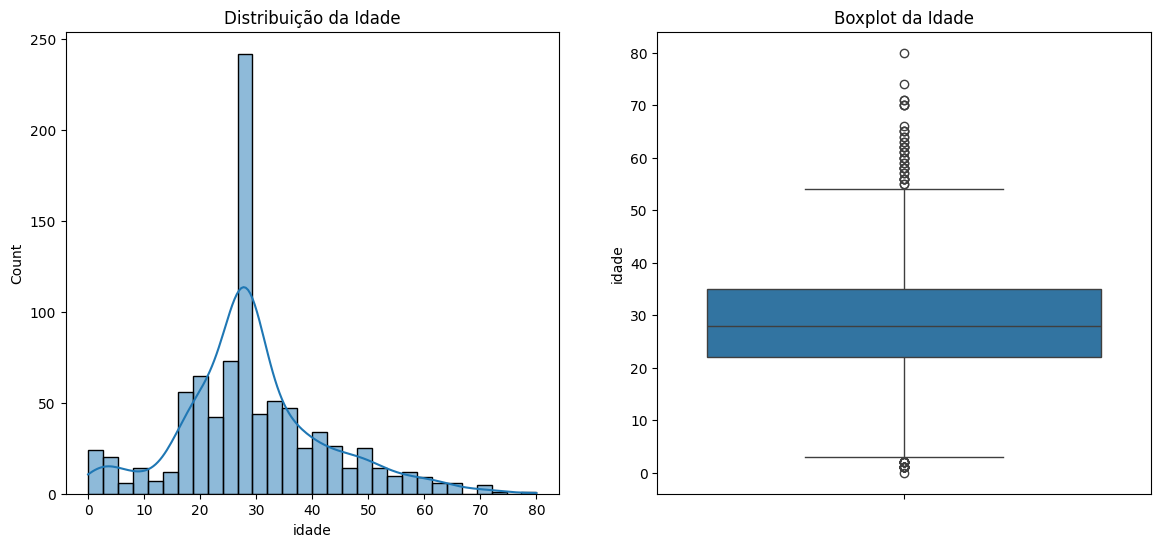

--- Estatísticas Descritivas da Idade ---
count    891.000000
mean      29.356902
std       13.017814
min        0.000000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: idade, dtype: float64

--- Identificação de Outliers (Z-Score > 3) ---


KeyError: 'idade_zscore'

In [38]:
# --- 4. TRATAMENTO DE DADOS OMISSOS ---
if 'nivel_cabine' in df.columns:
    df = df.drop(columns=['nivel_cabine'])

mediana_idade = df['idade'].median()
df['idade'] = df['idade'].fillna(mediana_idade).round().astype(int) 

moda_embarque = df['embarque'].mode()[0]
df['embarque'] = df['embarque'].fillna(moda_embarque)

# HISTOGRAMA + BOXPLOT juntos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df['idade'], kde=True, ax=ax1)
ax1.set_title('Distribuição da Idade')

sns.boxplot(y=df['idade'], ax=ax2)
ax2.set_title('Boxplot da Idade')

plt.show()
# Exibindo métricas descritivas detalhadas
print("--- Estatísticas Descritivas da Idade ---")
print(df['idade'].describe())

print("\n--- Identificação de Outliers (Z-Score > 3) ---")
outliers = df[df['idade_zscore'].abs() > 3]
print(f"Quantidade de outliers detectados: {len(outliers)}")

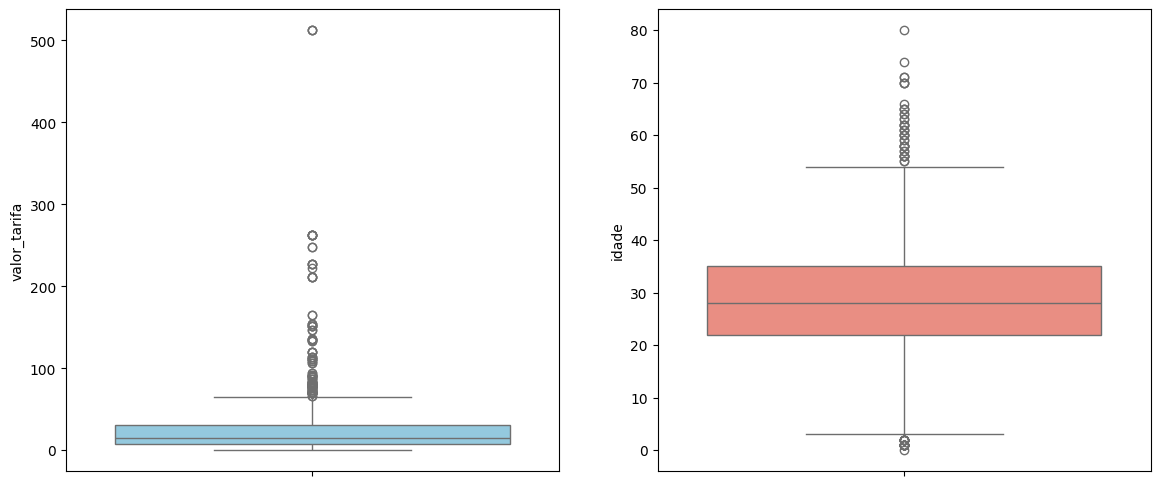

In [20]:
# --- 5. VISUALIZAÇÃO DE OUTLIERS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(y=df['valor_tarifa'], ax=ax1, color='skyblue')
sns.boxplot(y=df['idade'], ax=ax2, color='salmon')
plt.show()

In [22]:
# 6 e 7. TRATAMENTO DE OUTLIERS
limite_p95 = df['valor_tarifa'].quantile(0.95)
df['tarifa_tratada'] = df['valor_tarifa'].clip(upper=limite_p95)
plt.show()


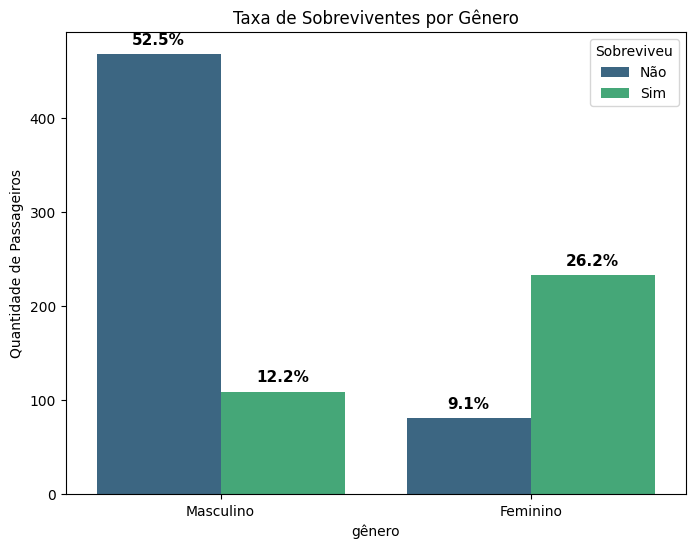

In [36]:
# 8. ANÁLISE: SOBREVIVÊNCIA POR GÊNERO (Com Porcentagem)
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='gênero', hue='sobreviveu', data=df, palette='viridis')

# Cálculo das porcentagens no topo das barras
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        # Calcula a porcentagem em relação ao total geral da base (len(df))
        percentage = (height / len(df)) * 100
        
        ax.annotate(f'{percentage:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=11, fontweight='bold', 
                    xytext=(0, 5), textcoords='offset points')

plt.title('Taxa de Sobreviventes por Gênero')
plt.legend(title='Sobreviveu', labels=['Não', 'Sim'])
plt.ylabel('Quantidade de Passageiros')
plt.show()

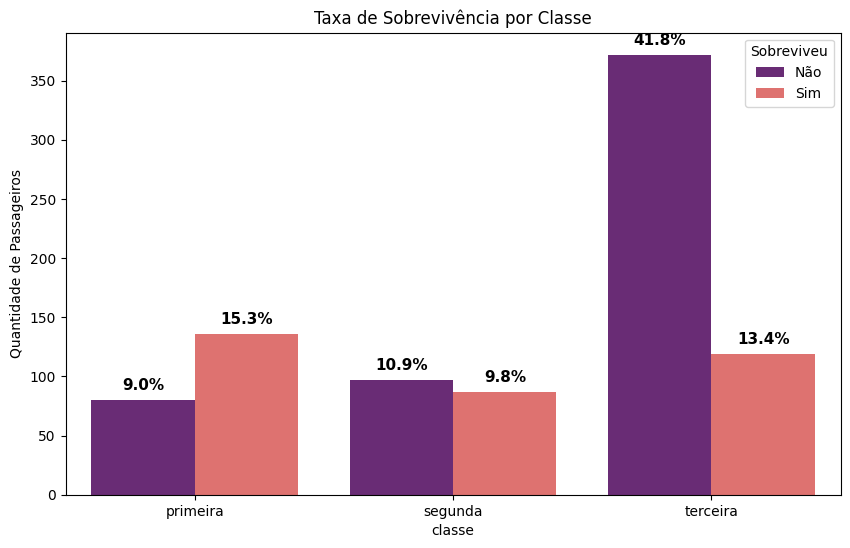

In [34]:
# 9. ANÁLISE: SOBREVIVÊNCIA POR CLASSE (Com Porcentagem)
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='classe', hue='sobreviveu', data=df, palette='magma', order=['primeira', 'segunda', 'terceira'])

# Inserção das porcentagens no topo de cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        # Porcentagem em relação ao total de passageiros (len(df))
        percentage = (height / len(df)) * 100
        
        ax.annotate(f'{percentage:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=11, fontweight='bold', 
                    xytext=(0, 5), textcoords='offset points')

plt.title('Taxa de Sobrevivência por Classe')
plt.legend(title='Sobreviveu', labels=['Não', 'Sim'])
plt.ylabel('Quantidade de Passageiros')
plt.show()

C:\Users\geova\AppData\Local\Temp\ipykernel_15972\1542618708.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='sobreviveu', y='idade', data=df, palette='Set2')


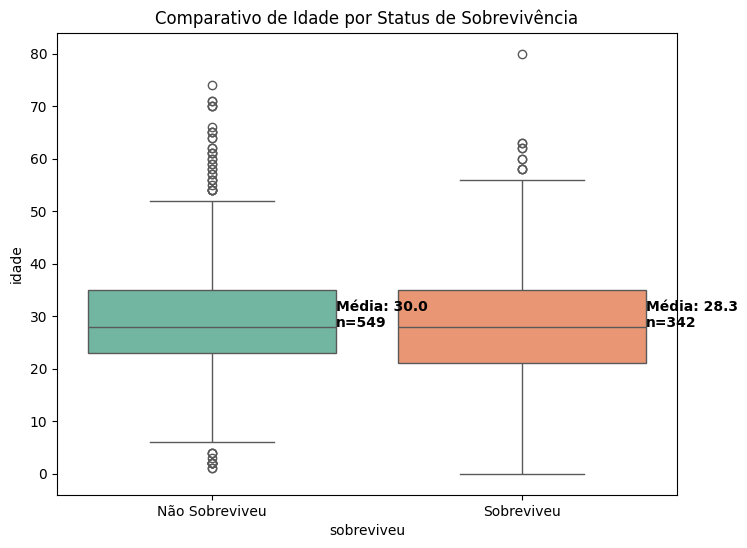

In [37]:
# 10. ANÁLISE: IDADE VS SOBREVIVÊNCIA
plt.figure(figsize=(8, 6))
ax = sns.boxplot(x='sobreviveu', y='idade', data=df, palette='Set2')

# Adicionando o N (quantidade) em cada categoria para o relatório
means = df.groupby('sobreviveu')['idade'].mean()
counts = df.groupby('sobreviveu')['idade'].count()

for i, line in enumerate(ax.get_lines()[4::6]): # Pega a linha da mediana
    x, y = line.get_xydata()[1]
    ax.text(x, y, f'Média: {means[i]:.1f}\nn={counts[i]}', 
            horizontalalignment='left', weight='bold', color='black')

plt.xticks([0, 1], ['Não Sobreviveu', 'Sobreviveu'])
plt.title('Comparativo de Idade por Status de Sobrevivência')
plt.show()